In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X = np.arange(10, 30, 0.13)
y = 2.222*X + 3.333

In [4]:
split = int(len(X)*0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [5]:
def plot_data(X_train, y_train, X_test, y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
        plt.xlabel('X') 
        plt.ylabel('y')
        plt.title('X vs y')
        plt.legend()
        plt.show()

In [6]:
w = np.random.randn()
b = np.random.randn()

In [8]:
def loss_fn(y_actual, y_out):
    return np.sum(np.square(y_actual - y_out)) / len(y_actual)

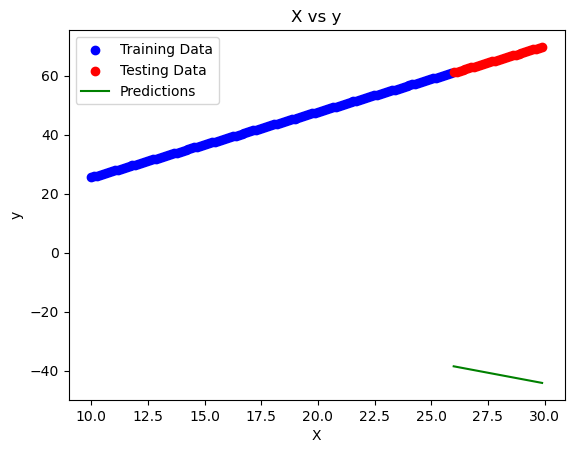

In [10]:
y_out = X_test*w + b
plot_data(X_train, y_train, X_test, y_test, predictions=y_out)

In [12]:
lr = 0.1
epochs = 100
train_loss_list, test_loss_list = [], []
for epoch in range(epochs):
    # Forward pass
    train_preds = X_train*w + b
    train_loss = loss_fn(y_train, train_preds)
    # Compute gradients
    gradientW = (-2/len(X_train)) * np.sum((y_train - train_preds)*X_train)
    gradientb = (-2/len(X_train)) * np.sum(y_train - train_preds)
    # Update parameters
    w = w - gradientW*lr
    b = b - gradientb*lr
    # Evaluate on test data
    test_preds = X_test*w + b
    test_loss = loss_fn(y_test, test_preds)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

/home/susan/miniconda3/envs/ds/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_11192/3423474167.py:2: RuntimeWarning: overflow encountered in square
  return np.sum(np.square(y_actual - y_out)) / len(y_actual)


In [13]:
y_out = X_test*w + b
plot_data(predictions=y_out)

TypeError: plot_data() missing 4 required positional arguments: 'X_train', 'y_train', 'X_test', and 'y_test'

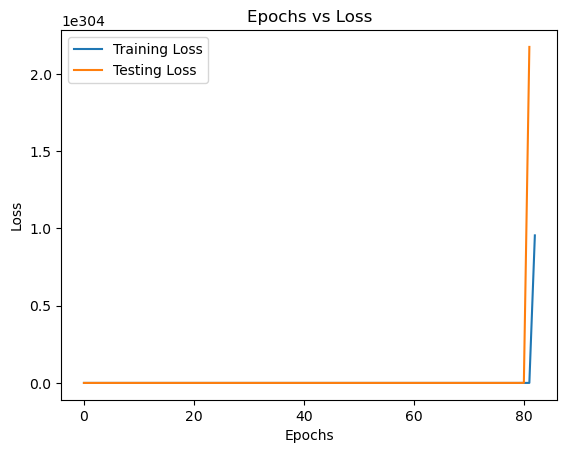

In [14]:
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss");
plt.xlabel("Epochs");
plt.ylabel("Loss")
plt.legend();
plt.show()